<a href="https://colab.research.google.com/github/Michele-Bufis/Ecg-cnn-embedded/blob/main/ecg_cnn_progetto_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificazione Patologie ECG con CNN Embedded
### Progetto completo: dati, GroupKFold Cross-Validation, modello finale ottimizzato e valutazione sul Test Set

Notebook unico e autosufficiente che documenta l'intero percorso: preparazione dati,
validazione robusta (GroupKFold), e costruzione/valutazione del modello finale con
pipeline gerarchica a due stadi, RR interval, augmentation su F, e soglie ottimizzate.

## 1. Setup ambiente

In [ ]:
!pip install wfdb -q

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.9 MB/s eta 0:00:00


## 2. Download completo del dataset (48 record) + mappatura AAMI

In [ ]:
record_names = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

dataset = {}

for rec_name in record_names:
    record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
    ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

    campioni_validi = []
    classi_valide = []
    for campione, simbolo in zip(ann.sample, ann.symbol):
        if simbolo in aami_map:
            campioni_validi.append(campione)
            classi_valide.append(aami_map[simbolo])

    dataset[rec_name] = {
        'signal': record.p_signal,
        'fs': record.fs,
        'beat_samples': np.array(campioni_validi),
        'beat_labels': np.array(classi_valide)
    }
    print(f'Record {rec_name}: {len(campioni_validi)} battiti validi')

print(f'\nTutti i {len(record_names)} record scaricati')

Record 100: 2273 battiti validi
Record 101: 1865 battiti validi
Record 102: 2187 battiti validi
Record 103: 2084 battiti validi
Record 104: 2229 battiti validi
Record 105: 2572 battiti validi
Record 106: 2027 battiti validi
Record 107: 2137 battiti validi
Record 108: 1763 battiti validi
Record 109: 2532 battiti validi
Record 111: 2124 battiti validi
Record 112: 2539 battiti validi
Record 113: 1795 battiti validi
Record 114: 1879 battiti validi
Record 115: 1953 battiti validi
Record 116: 2412 battiti validi
Record 117: 1535 battiti validi
Record 118: 2278 battiti validi
Record 119: 1987 battiti validi
Record 121: 1863 battiti validi
Record 122: 2476 battiti validi
Record 123: 1518 battiti validi
Record 124: 1619 battiti validi
Record 200: 2601 battiti validi
Record 201: 1963 battiti validi
Record 202: 2136 battiti validi
Record 203: 2980 battiti validi
Record 205: 2656 battiti validi
Record 207: 1860 battiti validi
Record 208: 2955 battiti validi
Record 209: 3005 battiti validi
Record 2

## 3. Preprocessing: filtro passa-banda

In [ ]:
from scipy.signal import butter, filtfilt

CANALE = 0

def filtro_passabanda(segnale, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, segnale)

for rec_name in dataset:
    segnale_grezzo = dataset[rec_name]['signal'][:, CANALE]
    dataset[rec_name]['signal_filtered'] = filtro_passabanda(segnale_grezzo, dataset[rec_name]['fs'])

print('Filtro passa-banda applicato a tutti i record.')

Filtro passa-banda applicato a tutti i record.


## 4. Segmentazione + calcolo RR interval (su tutto il dataset, split avverra' nel k-fold)

In [ ]:
FINESTRA_PRIMA = 100
FINESTRA_DOPO = 200

X = []
y = []
record_id = []
rr_interval = []

for rec_name in dataset:
    segnale = dataset[rec_name]['signal_filtered']
    campioni_battiti = dataset[rec_name]['beat_samples']
    classi_battiti = dataset[rec_name]['beat_labels']

    diff_rr = np.diff(campioni_battiti)
    rr_mediano = np.median(diff_rr) if len(diff_rr) > 0 else 0

    for idx, (campione, classe) in enumerate(zip(campioni_battiti, classi_battiti)):
        inizio = campione - FINESTRA_PRIMA
        fine = campione + FINESTRA_DOPO
        if inizio < 0 or fine > len(segnale):
            continue

        segmento = segnale[inizio:fine]
        media = np.mean(segmento)
        std = np.std(segmento)
        segmento_normalizzato = (segmento - media) / (std + 1e-8)

        rr = (campione - campioni_battiti[idx - 1]) if idx > 0 else rr_mediano

        X.append(segmento_normalizzato)
        y.append(classe)
        record_id.append(rec_name)
        rr_interval.append(rr)

X = np.array(X).reshape(-1, FINESTRA_PRIMA + FINESTRA_DOPO, 1)
y = np.array(y)
record_id = np.array(record_id)
rr_interval = np.array(rr_interval, dtype=float)

classe_to_int = {classe: i for i, classe in enumerate(sorted(np.unique(y)))}
int_to_classe = {i: c for c, i in classe_to_int.items()}
num_classi = len(classe_to_int)
y_int = np.array([classe_to_int[c] for c in y])

print(f'Segmenti totali: {len(X)}, classi: {classe_to_int}')

Segmenti totali: 109446, classi: {np.str_('F'): 0, np.str_('N'): 1, np.str_('Q'): 2, np.str_('S'): 3, np.str_('V'): 4}


## 5. Salvataggio su Drive (per riuso rapido)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'
os.makedirs(SALVA_DIR, exist_ok=True)

np.save(f'{SALVA_DIR}/X_full.npy', X)
np.save(f'{SALVA_DIR}/y_int_full.npy', y_int)
np.save(f'{SALVA_DIR}/record_id_full.npy', record_id)
np.save(f'{SALVA_DIR}/rr_full.npy', rr_interval)

print('Dataset completo (non splittato) salvato su Drive per uso con GroupKFold.')

Mounted at /content/drive
Dataset completo (non splittato) salvato su Drive per uso con GroupKFold.


## 0. Avvio rapido alternativo (se gia' salvato)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'

X = np.load(f'{SALVA_DIR}/X_full.npy')
y_int = np.load(f'{SALVA_DIR}/y_int_full.npy')
record_id = np.load(f'{SALVA_DIR}/record_id_full.npy')
rr_interval = np.load(f'{SALVA_DIR}/rr_full.npy')

classe_to_int = {'F': 0, 'N': 1, 'Q': 2, 'S': 3, 'V': 4}
int_to_classe = {i: c for c, i in classe_to_int.items()}
num_classi = len(classe_to_int)

print(f'Dataset completo ricaricato: {X.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset completo ricaricato: (109446, 300, 1)


## 6. Architettura e funzioni riutilizzabili

In [ ]:
from tensorflow.keras import layers, models, Input
import tensorflow as tf

def costruisci_modello_duale(lunghezza_finestra, num_classi):
    input_forma = Input(shape=(lunghezza_finestra, 1), name='forma_donda')
    x = layers.Conv1D(16, kernel_size=9, padding='same')(input_forma)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(32, kernel_size=7, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)

    input_rr = Input(shape=(1,), name='rr_interval')
    r = layers.Dense(16, activation='relu')(input_rr)
    r = layers.Dense(8, activation='relu')(r)

    combinato = layers.Concatenate()([x, r])
    output = layers.Dense(num_classi, activation='softmax')(combinato)

    return models.Model(inputs=[input_forma, input_rr], outputs=output)

def augmenta_segmento(segmento, rng):
    aug = segmento.copy()
    shift = rng.integers(-5, 6)
    aug = np.roll(aug, shift)
    aug = aug + rng.normal(0, 0.03, size=aug.shape)
    fattore_scala = rng.uniform(0.9, 1.1)
    return aug * fattore_scala

from sklearn.metrics import f1_score

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val_list, y_val_int):
        super().__init__()
        self.X_val_list = X_val_list
        self.y_val_int = y_val_int

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val_list, verbose=0), axis=1)
        macro_f1 = f1_score(self.y_val_int, y_pred, average='macro', zero_division=0)
        logs['val_macro_f1'] = macro_f1

## 7. GroupKFold Cross-Validation (5 fold, raggruppati per record)

Per ogni fold: split per record, normalizzazione RR calcolata SOLO sul training del fold, augmentation su F calcolata SOLO sul training del fold (mai su validation, per non introdurre leakage tra fold), training e valutazione.

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import pickle
import os

N_FOLD = 5
gkf = GroupKFold(n_splits=N_FOLD)

etichette_tutte = list(range(num_classi))
nomi_classi = [int_to_classe[i] for i in range(num_classi)]
indice_F = classe_to_int['F']

# --- Percorso file di checkpoint su Drive ---
CHECKPOINT_PATH = f'{SALVA_DIR}/groupkfold_risultati_v2.pkl'

# --- Ripresa da sessione precedente: carica i fold gia' completati, se esistono ---
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'rb') as f:
        risultati_fold = pickle.load(f)
    fold_completati = {r['fold'] for r in risultati_fold}
    print(f'Checkpoint trovato: {len(fold_completati)} fold gia completati -> {sorted(fold_completati)}')
else:
    risultati_fold = []
    fold_completati = set()
    print('Nessun checkpoint trovato, si parte da zero.')

tutti_gli_split = list(gkf.split(X, y_int, groups=record_id))

for fold_num, (idx_train, idx_val) in enumerate(tutti_gli_split):
    numero_fold_umano = fold_num + 1

    if numero_fold_umano in fold_completati:
        print(f'\n===== FOLD {numero_fold_umano}/{N_FOLD} -- GIA COMPLETATO, salto =====')
        continue

    print(f'\n===== FOLD {numero_fold_umano}/{N_FOLD} =====')

    X_tr, y_tr, rr_tr = X[idx_train], y_int[idx_train], rr_interval[idx_train]
    X_va, y_va, rr_va = X[idx_val], y_int[idx_val], rr_interval[idx_val]

    rr_media = rr_tr.mean()
    rr_std = rr_tr.std()
    rr_tr_norm = (rr_tr - rr_media) / (rr_std + 1e-8)
    rr_va_norm = (rr_va - rr_media) / (rr_std + 1e-8)

    rng = np.random.default_rng(42 + fold_num)
    idx_F = np.where(y_tr == indice_F)[0]
    X_aug, rr_aug, y_aug = [], [], []
    for idx in idx_F:
        seg = X_tr[idx, :, 0]
        rr_val_orig = rr_tr_norm[idx]
        for _ in range(8):
            X_aug.append(augmenta_segmento(seg, rng))
            rr_aug.append(rr_val_orig)
            y_aug.append(indice_F)

    if len(X_aug) > 0:
        X_aug = np.array(X_aug).reshape(-1, X.shape[1], 1)
        rr_aug = np.array(rr_aug)
        y_aug = np.array(y_aug)
        X_tr_final = np.concatenate([X_tr, X_aug], axis=0)
        rr_tr_final = np.concatenate([rr_tr_norm, rr_aug], axis=0)
        y_tr_final = np.concatenate([y_tr, y_aug], axis=0)
    else:
        X_tr_final, rr_tr_final, y_tr_final = X_tr, rr_tr_norm, y_tr

    classi_presenti_train = np.unique(y_tr_final)
    pesi = compute_class_weight(class_weight='balanced', classes=classi_presenti_train, y=y_tr_final)
    class_weights = dict(zip(classi_presenti_train, pesi))

    model = costruisci_modello_duale(X.shape[1], num_classi)
    model.compile(optimizer=Adam(learning_rate=0.0003), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    macro_f1_cb = MacroF1Callback([X_va, rr_va_norm], y_va)
    early_stop = EarlyStopping(monitor='val_macro_f1', mode='max', patience=12, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

    model.fit(
        [X_tr_final, rr_tr_final], y_tr_final,
        validation_data=([X_va, rr_va_norm], y_va),
        epochs=40, batch_size=64, class_weight=class_weights,
        callbacks=[macro_f1_cb, early_stop, reduce_lr], verbose=1
    )

    y_pred = np.argmax(model.predict([X_va, rr_va_norm], verbose=0), axis=1)

    macro_f1 = f1_score(y_va, y_pred, labels=etichette_tutte, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_va, y_pred)
    f1_per_classe = f1_score(y_va, y_pred, labels=etichette_tutte, average=None, zero_division=0)
    classi_presenti_val = sorted(np.unique(y_va))
    cm_fold = confusion_matrix(y_va, y_pred, labels=etichette_tutte)

    print(f'\n--- Risultato Fold {numero_fold_umano} ---')
    print(f'Record nel validation: {sorted(set(record_id[idx_val]))}')
    print(f'Classi presenti nel validation: {[int_to_classe[c] for c in classi_presenti_val]}')
    print(f'Macro F1: {macro_f1:.4f} | Balanced Accuracy: {bal_acc:.4f}')
    print(classification_report(y_va, y_pred, labels=etichette_tutte, target_names=nomi_classi, zero_division=0))

    risultati_fold.append({
        'fold': numero_fold_umano,
        'macro_f1': macro_f1,
        'balanced_accuracy': bal_acc,
        'f1_per_classe': f1_per_classe,
        'classi_presenti': classi_presenti_val,
        'confusion_matrix': cm_fold
    })

    # --- Salvataggio incrementale: appena finito questo fold, lo scriviamo subito su Drive ---
    with open(CHECKPOINT_PATH, 'wb') as f:
        pickle.dump(risultati_fold, f)
    print(f'>>> Fold {numero_fold_umano} salvato su Drive in {CHECKPOINT_PATH}')

print(f'\n===== Fold completati finora: {len(risultati_fold)}/{N_FOLD} =====')

Nessun checkpoint trovato, si parte da zero.

===== FOLD 1/5 =====
Epoch 1/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.8273 - loss: 0.4818 - val_accuracy: 0.6215 - val_loss: 0.8497 - val_macro_f1: 0.3876 - learning_rate: 3.0000e-04
Epoch 2/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9173 - loss: 0.2124 - val_accuracy: 0.6884 - val_loss: 0.6877 - val_macro_f1: 0.3859 - learning_rate: 3.0000e-04
Epoch 3/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 68s 46ms/step - accuracy: 0.9312 - loss: 0.1773 - val_accuracy: 0.3916 - val_loss: 1.8017 - val_macro_f1: 0.2968 - learning_rate: 3.0000e-04
Epoch 4/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.9375 - loss: 0.1594 - val_accuracy: 0.9007 - val_loss: 0.2865 - val_macro_f1: 0.5376 - learning_rate: 3.0000e-04
Epoch 5/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9404 - loss: 0.1493 - val_accuracy: 0.6593 - val_loss: 0.7041 - val_macro_f1: 0.4068 - learning_rate: 3.0000e-04
Epoch 6/40
1481/14

## 8. Aggregazione dei risultati tra i fold

===== RISULTATI AGGREGATI GROUPKFOLD =====
Macro F1: media=0.5005, std=0.0688
Balanced Accuracy: media=0.5387, std=0.0778

F1 medio per classe (media sui fold dove la classe era presente nel validation):
  F: media=0.0524 (presente in 5/5 fold)
  N: media=0.9158 (presente in 5/5 fold)
  Q: media=0.5542 (presente in 5/5 fold)
  S: media=0.2155 (presente in 5/5 fold)
  V: media=0.7648 (presente in 5/5 fold)


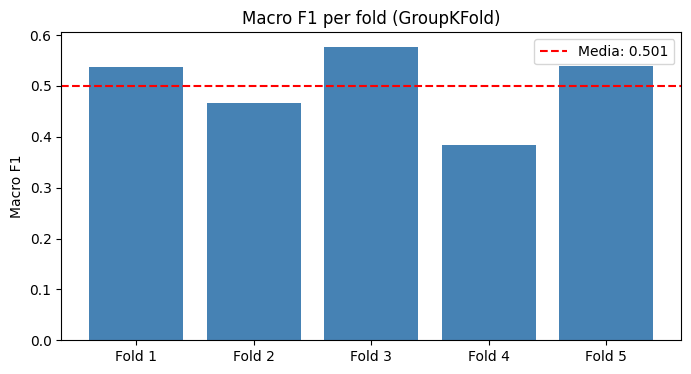

In [ ]:
macro_f1_tutti = [r['macro_f1'] for r in risultati_fold]
bal_acc_tutti = [r['balanced_accuracy'] for r in risultati_fold]

print('===== RISULTATI AGGREGATI GROUPKFOLD =====')
print(f'Macro F1: media={np.mean(macro_f1_tutti):.4f}, std={np.std(macro_f1_tutti):.4f}')
print(f'Balanced Accuracy: media={np.mean(bal_acc_tutti):.4f}, std={np.std(bal_acc_tutti):.4f}')

print('\nF1 medio per classe (media sui fold dove la classe era presente nel validation):')
f1_matrix = np.array([r['f1_per_classe'] for r in risultati_fold])
for i, nome in enumerate(nomi_classi):
    fold_con_classe = [r['f1_per_classe'][i] for r in risultati_fold if i in r['classi_presenti']]
    if fold_con_classe:
        print(f'  {nome}: media={np.mean(fold_con_classe):.4f} (presente in {len(fold_con_classe)}/{N_FOLD} fold)')
    else:
        print(f'  {nome}: MAI presente nel validation in nessun fold')

plt.figure(figsize=(8, 4))
plt.bar([f'Fold {r["fold"]}' for r in risultati_fold], macro_f1_tutti, color='steelblue')
plt.axhline(np.mean(macro_f1_tutti), color='red', linestyle='--', label=f'Media: {np.mean(macro_f1_tutti):.3f}')
plt.title('Macro F1 per fold (GroupKFold)')
plt.ylabel('Macro F1')
plt.legend()
plt.show()

## 8bis. Confusion Matrix Aggregata (somma di tutti i fold GroupKFold)

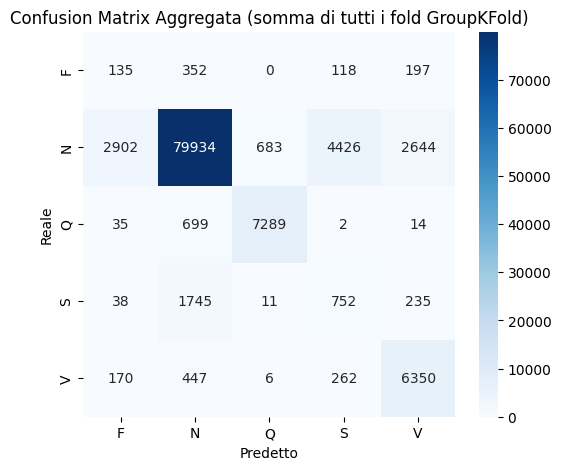

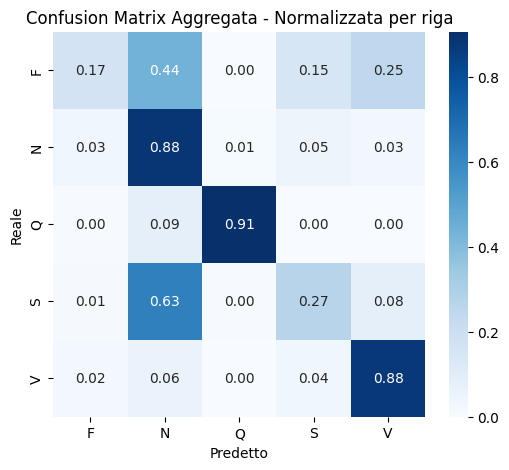

In [ ]:
import seaborn as sns

cm_totale = np.sum([r['confusion_matrix'] for r in risultati_fold], axis=0)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_totale, annot=True, fmt='d', xticklabels=nomi_classi, yticklabels=nomi_classi, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale')
plt.title('Confusion Matrix Aggregata (somma di tutti i fold GroupKFold)')
plt.show()

cm_normalizzata = cm_totale.astype(float) / cm_totale.sum(axis=1, keepdims=True)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalizzata, annot=True, fmt='.2f', xticklabels=nomi_classi, yticklabels=nomi_classi, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale')
plt.title('Confusion Matrix Aggregata - Normalizzata per riga')
plt.show()

---
# Fase Finale: Modello Definitivo Ottimizzato + Valutazione sul Test Set

Con la stima di riferimento ottenuta dal GroupKFold (Sezioni precedenti), si procede
ad allenare il modello finale (pipeline gerarchica a due stadi), ottimizzare la soglia
di decisione dello Stadio 1 per il recall e calibrare le soglie di confidenza per
classe nello Stadio 2, per poi valutare il risultato conclusivo una tantum sul test set.

## 0. Caricamento dataset completo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'

X = np.load(f'{SALVA_DIR}/X_full.npy')
y_int = np.load(f'{SALVA_DIR}/y_int_full.npy')
record_id = np.load(f'{SALVA_DIR}/record_id_full.npy')
rr_interval = np.load(f'{SALVA_DIR}/rr_full.npy')

classe_to_int = {'F': 0, 'N': 1, 'Q': 2, 'S': 3, 'V': 4}
int_to_classe = {i: c for c, i in classe_to_int.items()}
num_classi = len(classe_to_int)
indice_N = classe_to_int['N']

print(f'Dataset completo: {X.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset completo: (109446, 300, 1)


## 1. Split: Train+Val (per allenare) vs Test (intoccato fino alla Sezione 9)

Stesso split di record usato in tutto il progetto (random_state=42).

In [ ]:
from sklearn.model_selection import train_test_split

record_names = sorted(set(record_id.tolist()))
record_unici = np.array(record_names)

record_train, record_valtest = train_test_split(record_unici, test_size=0.30, random_state=42)
record_val, record_test = train_test_split(record_valtest, test_size=0.50, random_state=42)
record_trainfinal = np.concatenate([record_train, record_val])

mask_trainfinal = np.isin(record_id, record_trainfinal)
mask_test = np.isin(record_id, record_test)

X_trainfinal, y_trainfinal, rr_trainfinal = X[mask_trainfinal], y_int[mask_trainfinal], rr_interval[mask_trainfinal]
X_test, y_test, rr_test = X[mask_test], y_int[mask_test], rr_interval[mask_test]

print(f'Training+Val: {len(y_trainfinal)} segmenti, {len(record_trainfinal)} record')
print(f'Test (mai usato fino alla Sez. 9): {len(y_test)} segmenti, {len(record_test)} record')

Training+Val: 90306 segmenti, 40 record
Test (mai usato fino alla Sez. 9): 19140 segmenti, 8 record


## 2. Sotto-split interno: Training vs Validation (per training, soglie, Early Stopping)

In [ ]:
record_train_int, record_val_int = train_test_split(record_trainfinal, test_size=0.15, random_state=42)

mask_tr = np.isin(record_id[mask_trainfinal], record_train_int)
mask_va = np.isin(record_id[mask_trainfinal], record_val_int)

X_tr, y_tr, rr_tr = X_trainfinal[mask_tr], y_trainfinal[mask_tr], rr_trainfinal[mask_tr]
X_va, y_va, rr_va = X_trainfinal[mask_va], y_trainfinal[mask_va], rr_trainfinal[mask_va]

rr_media = rr_tr.mean()
rr_std = rr_tr.std()
rr_tr_norm = (rr_tr - rr_media) / (rr_std + 1e-8)
rr_va_norm = (rr_va - rr_media) / (rr_std + 1e-8)
rr_test_norm = (rr_test - rr_media) / (rr_std + 1e-8)

print(f'Training interno: {len(y_tr)} segmenti')
print(f'Validation interno: {len(y_va)} segmenti')

Training interno: 76808 segmenti
Validation interno: 13498 segmenti


## 3. Architettura duale e funzioni riutilizzabili

In [ ]:
from tensorflow.keras import layers, models, Input
import tensorflow as tf
from sklearn.metrics import f1_score, confusion_matrix, classification_report, recall_score, precision_score
import seaborn as sns

def costruisci_modello_duale(lunghezza_finestra, num_output, attivazione_finale):
    input_forma = Input(shape=(lunghezza_finestra, 1), name='forma_donda')
    x = layers.Conv1D(16, kernel_size=9, padding='same')(input_forma)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(32, kernel_size=7, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)

    input_rr = Input(shape=(1,), name='rr_interval')
    r = layers.Dense(16, activation='relu')(input_rr)
    r = layers.Dense(8, activation='relu')(r)

    combinato = layers.Concatenate()([x, r])
    output = layers.Dense(num_output, activation=attivazione_finale)(combinato)
    return models.Model(inputs=[input_forma, input_rr], outputs=output)

def augmenta_segmento(segmento, rng):
    aug = segmento.copy()
    shift = rng.integers(-5, 6)
    aug = np.roll(aug, shift)
    aug = aug + rng.normal(0, 0.03, size=aug.shape)
    return aug * rng.uniform(0.9, 1.1)

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val_list, y_val_int):
        super().__init__()
        self.X_val_list = X_val_list
        self.y_val_int = y_val_int
    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val_list, verbose=0), axis=1)
        logs['val_macro_f1'] = f1_score(self.y_val_int, y_pred, average='macro', zero_division=0)

## 4. Stadio 1 -- Training: N vs Anomalo (con RR interval)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

y_tr_bin = (y_tr != indice_N).astype(int)
y_va_bin = (y_va != indice_N).astype(int)
y_test_bin = (y_test != indice_N).astype(int)

pesi_s1 = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_tr_bin)
class_weights_s1 = {0: pesi_s1[0], 1: pesi_s1[1]}

model_stadio1 = costruisci_modello_duale(X.shape[1], num_output=1, attivazione_finale='sigmoid')
model_stadio1.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])

early_stop_s1 = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr_s1 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_s1 = model_stadio1.fit(
    [X_tr, rr_tr_norm], y_tr_bin,
    validation_data=([X_va, rr_va_norm], y_va_bin),
    epochs=60, batch_size=64, class_weight=class_weights_s1,
    callbacks=[early_stop_s1, reduce_lr_s1], verbose=1
)

Epoch 1/60
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step - accuracy: 0.9300 - loss: 0.2598 - val_accuracy: 0.6086 - val_loss: 1.4156 - learning_rate: 3.0000e-04
Epoch 2/60
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.9736 - loss: 0.1320 - val_accuracy: 0.6234 - val_loss: 1.2431 - learning_rate: 3.0000e-04
Epoch 3/60
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 54s 45ms/step - accuracy: 0.9762 - loss: 0.1110 - val_accuracy: 0.7405 - val_loss: 0.8026 - learning_rate: 3.0000e-04
Epoch 4/60
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 56s 47ms/step - accuracy: 0.9781 - loss: 0.1011 - val_accuracy: 0.8116 - val_loss: 0.3482 - learning_rate: 3.0000e-04
Epoch 5/60
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.9788 - loss: 0.0947 - val_accuracy: 0.6519 - val_loss: 1.3424 - learning_rate: 3.0000e-04
Epoch 6/60
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 56s 46ms/step - accuracy: 0.9808 - loss: 0.0878 - val_accuracy: 0.7547 - val_loss: 0.5254 - learning_rate: 3.0000e-04
Epoch 7/60
1201/1201 ━━━━━━━━━━━━━━━━━━━

## 5. Stadio 1 -- Ottimizzazione soglia di decisione per il recall

Cerchiamo la soglia (invece del default 0.5) che massimizza il recall sugli anomali senza far crollare troppo la precisione -- attacca direttamente il collo di bottiglia identificato nel Tentativo 7 (recall 0.74 con soglia default).

In [ ]:
probabilita_s1_val = model_stadio1.predict([X_va, rr_va_norm]).flatten()

soglie_s1 = np.arange(0.10, 0.55, 0.05)
risultati_s1 = []
for soglia in soglie_s1:
    pred_bin = (probabilita_s1_val >= soglia).astype(int)
    recall_anom = recall_score(y_va_bin, pred_bin, pos_label=1)
    precision_anom = precision_score(y_va_bin, pred_bin, pos_label=1, zero_division=0)
    risultati_s1.append({'soglia': round(soglia, 2), 'recall_anomali': round(recall_anom, 4), 'precision_anomali': round(precision_anom, 4)})

df_s1 = pd.DataFrame(risultati_s1)
print(df_s1.to_string(index=False))
print('\nScegli SOGLIA_S1 nella cella successiva in base a questa tabella.')

422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
 soglia  recall_anomali  precision_anomali
   0.10          0.8915             0.4886
   0.15          0.8735             0.5416
   0.20          0.8517             0.5911
   0.25          0.8356             0.6436
   0.30          0.8115             0.6860
   0.35          0.7868             0.7253
   0.40          0.7523             0.7487
   0.45          0.7058             0.7583
   0.50          0.6618             0.7659

Scegli SOGLIA_S1 nella cella successiva in base a questa tabella.


In [ ]:
SOGLIA_S1 = 0.30  # AGGIORNA in base alla tabella sopra

pred_s1_va_ottimizzata = (probabilita_s1_val >= SOGLIA_S1).astype(int)
print(f'Con soglia {SOGLIA_S1}:')
print(f'  Recall anomali:    {recall_score(y_va_bin, pred_s1_va_ottimizzata, pos_label=1):.4f}')
print(f'  Precision anomali: {precision_score(y_va_bin, pred_s1_va_ottimizzata, pos_label=1, zero_division=0):.4f}')

Con soglia 0.3:
  Recall anomali:    0.8115
  Precision anomali: 0.6860


## 6. Stadio 2 -- Training: S/V/F/Q su soli anomali (RR interval + augmentation su F)

In [ ]:
mask_anom_tr = y_tr != indice_N
mask_anom_va = y_va != indice_N

X_tr_anom = X_tr[mask_anom_tr]
rr_tr_anom = rr_tr_norm[mask_anom_tr]
X_va_anom = X_va[mask_anom_va]
rr_va_anom = rr_va_norm[mask_anom_va]

classi_anomale = sorted([c for c in classe_to_int if c != 'N'])
classe_to_int_s2 = {c: i for i, c in enumerate(classi_anomale)}
int_to_classe_s2 = {i: c for c, i in classe_to_int_s2.items()}
nomi_s2 = [int_to_classe_s2[i] for i in range(len(classi_anomale))]

y_tr_s2 = np.array([classe_to_int_s2[int_to_classe[i]] for i in y_tr[mask_anom_tr]])
y_va_s2 = np.array([classe_to_int_s2[int_to_classe[i]] for i in y_va[mask_anom_va]])

print('Mappa Stadio 2:', classe_to_int_s2)
for c, i in classe_to_int_s2.items():
    print(f'  {c}: {(y_tr_s2 == i).sum()} esempi nel training anomalo')

Mappa Stadio 2: {'F': 0, 'Q': 1, 'S': 2, 'V': 3}
  F: 786 esempi nel training anomalo
  Q: 4164 esempi nel training anomalo
  S: 2449 esempi nel training anomalo
  V: 5993 esempi nel training anomalo


In [ ]:
rng = np.random.default_rng(42)
indice_F_s2 = classe_to_int_s2['F']
idx_F_s2 = np.where(y_tr_s2 == indice_F_s2)[0]

X_aug, rr_aug, y_aug = [], [], []
for idx in idx_F_s2:
    seg = X_tr_anom[idx, :, 0]
    rr_o = rr_tr_anom[idx]
    for _ in range(8):
        X_aug.append(augmenta_segmento(seg, rng))
        rr_aug.append(rr_o)
        y_aug.append(indice_F_s2)

X_aug = np.array(X_aug).reshape(-1, X.shape[1], 1)
rr_aug = np.array(rr_aug)
y_aug = np.array(y_aug)

X_tr_s2_final = np.concatenate([X_tr_anom, X_aug], axis=0)
rr_tr_s2_final = np.concatenate([rr_tr_anom, rr_aug], axis=0)
y_tr_s2_final = np.concatenate([y_tr_s2, y_aug], axis=0)

print(f'Training Stadio 2 dopo augmentation: {len(y_tr_s2_final)} esempi (F: {(y_tr_s2_final==indice_F_s2).sum()})')

Training Stadio 2 dopo augmentation: 19680 esempi (F: 7074)


In [ ]:
pesi_s2 = compute_class_weight(class_weight='balanced', classes=np.unique(y_tr_s2_final), y=y_tr_s2_final)
class_weights_s2 = dict(zip(np.unique(y_tr_s2_final), pesi_s2))

model_stadio2 = costruisci_modello_duale(X.shape[1], num_output=len(classi_anomale), attivazione_finale='softmax')
model_stadio2.compile(optimizer=Adam(learning_rate=0.0003), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

macro_f1_cb_s2 = MacroF1Callback([X_va_anom, rr_va_anom], y_va_s2)
early_stop_s2 = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15, restore_best_weights=True)
reduce_lr_s2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_s2 = model_stadio2.fit(
    [X_tr_s2_final, rr_tr_s2_final], y_tr_s2_final,
    validation_data=([X_va_anom, rr_va_anom], y_va_s2),
    epochs=60, batch_size=64, class_weight=class_weights_s2,
    callbacks=[macro_f1_cb_s2, early_stop_s2, reduce_lr_s2], verbose=1
)

Epoch 1/60
308/308 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.7871 - loss: 0.6466 - val_accuracy: 0.2070 - val_loss: 0.9401 - val_macro_f1: 0.1046 - learning_rate: 3.0000e-04
Epoch 2/60
308/308 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.9520 - loss: 0.2234 - val_accuracy: 0.5703 - val_loss: 0.7632 - val_macro_f1: 0.4785 - learning_rate: 3.0000e-04
Epoch 3/60
308/308 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9642 - loss: 0.1478 - val_accuracy: 0.8437 - val_loss: 0.5399 - val_macro_f1: 0.4228 - learning_rate: 3.0000e-04
Epoch 4/60
308/308 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9701 - loss: 0.1142 - val_accuracy: 0.8006 - val_loss: 0.6722 - val_macro_f1: 0.5615 - learning_rate: 3.0000e-04
Epoch 5/60
308/308 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9743 - loss: 0.0934 - val_accuracy: 0.9327 - val_loss: 0.1992 - val_macro_f1: 0.6342 - learning_rate: 3.0000e-04
Epoch 6/60
308/308 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9755 - loss: 0.0834 - val_a

## 7. Stadio 2 -- Calibrazione soglia di confidenza per classe

Invece di una soglia globale uguale per tutte le classi, cerchiamo la soglia ottimale separatamente per ciascuna -- attacca il problema di overconfidence osservato su Q (classificato con sicurezza ma erroneamente).

In [ ]:
probabilita_s2_val = model_stadio2.predict([X_va_anom, rr_va_anom])
classe_predetta_s2_val = np.argmax(probabilita_s2_val, axis=1)
confidenza_s2_val = np.max(probabilita_s2_val, axis=1)

soglie_per_classe = {}
for i, nome_classe in enumerate(nomi_s2):
    mask_classe = classe_predetta_s2_val == i
    if mask_classe.sum() == 0:
        soglie_per_classe[i] = 0.5
        print(f'{nome_classe}: mai predetta nel validation, soglia default 0.5')
        continue
    migliore_f1, migliore_soglia = -1, 0.3
    for soglia in np.arange(0.2, 0.95, 0.05):
        mask_conf = mask_classe & (confidenza_s2_val >= soglia)
        if mask_conf.sum() == 0:
            continue
        f1_classe = f1_score(y_va_s2[mask_conf], classe_predetta_s2_val[mask_conf], labels=[i], average='macro', zero_division=0)
        if f1_classe > migliore_f1:
            migliore_f1, migliore_soglia = f1_classe, soglia
    soglie_per_classe[i] = round(migliore_soglia, 2)
    print(f'{nome_classe}: soglia ottimale = {migliore_soglia:.2f} (F1 a quella soglia: {migliore_f1:.4f})')

print('\nSoglie finali per classe (Stadio 2):', {nomi_s2[k]: v for k, v in soglie_per_classe.items()})

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
F: soglia ottimale = 0.55 (F1 a quella soglia: 0.4000)
Q: soglia ottimale = 0.85 (F1 a quella soglia: 0.9993)
S: soglia ottimale = 0.55 (F1 a quella soglia: 1.0000)
V: soglia ottimale = 0.90 (F1 a quella soglia: 0.8889)

Soglie finali per classe (Stadio 2): {'F': np.float64(0.55), 'Q': np.float64(0.85), 'S': np.float64(0.55), 'V': np.float64(0.9)}


## 8. Pipeline combinata -- Verifica su Validation (prima del test)

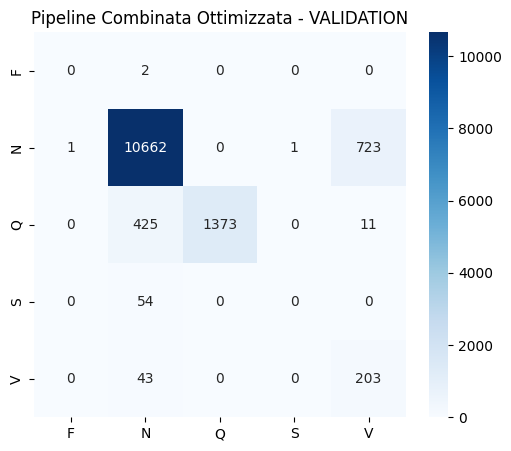

              precision    recall  f1-score   support

           F       0.00      0.00      0.00         2
           N       0.95      0.94      0.94     11387
           Q       1.00      0.76      0.86      1809
           S       0.00      0.00      0.00        54
           V       0.22      0.83      0.34       246

    accuracy                           0.91     13498
   macro avg       0.43      0.50      0.43     13498
weighted avg       0.94      0.91      0.92     13498

Macro F1 (validation): 0.4302


In [ ]:
def pipeline_combinata(X_input, rr_input, model_s1, soglia_s1, model_s2, soglie_classe_s2, indice_N, classe_to_int, int_to_classe_s2):
    prob_s1 = model_s1.predict([X_input, rr_input], verbose=0).flatten()
    pred_s1 = (prob_s1 >= soglia_s1).astype(int)

    pred_finale = np.full(len(X_input), indice_N)
    idx_anomali = np.where(pred_s1 == 1)[0]

    if len(idx_anomali) > 0:
        prob_s2 = model_s2.predict([X_input[idx_anomali], rr_input[idx_anomali]], verbose=0)
        classe_s2 = np.argmax(prob_s2, axis=1)
        conf_s2 = np.max(prob_s2, axis=1)

        for pos, idx in enumerate(idx_anomali):
            ci = classe_s2[pos]
            if conf_s2[pos] >= soglie_classe_s2[ci]:
                pred_finale[idx] = classe_to_int[int_to_classe_s2[ci]]
            # altrimenti resta N (default prudente se sotto soglia per quella classe)

    return pred_finale

pred_va_finale = pipeline_combinata(X_va, rr_va_norm, model_stadio1, SOGLIA_S1, model_stadio2, soglie_per_classe, indice_N, classe_to_int, int_to_classe_s2)

nomi_classi_finali = [int_to_classe[i] for i in range(num_classi)]
cm_va = confusion_matrix(y_va, pred_va_finale, labels=list(range(num_classi)))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_va, annot=True, fmt='d', xticklabels=nomi_classi_finali, yticklabels=nomi_classi_finali, cmap='Blues')
plt.title('Pipeline Combinata Ottimizzata - VALIDATION')
plt.show()

print(classification_report(y_va, pred_va_finale, labels=list(range(num_classi)), target_names=nomi_classi_finali, zero_division=0))
print(f"Macro F1 (validation): {f1_score(y_va, pred_va_finale, labels=list(range(num_classi)), average='macro', zero_division=0):.4f}")

## 9. VALUTAZIONE FINALE SUL TEST SET (unica volta)

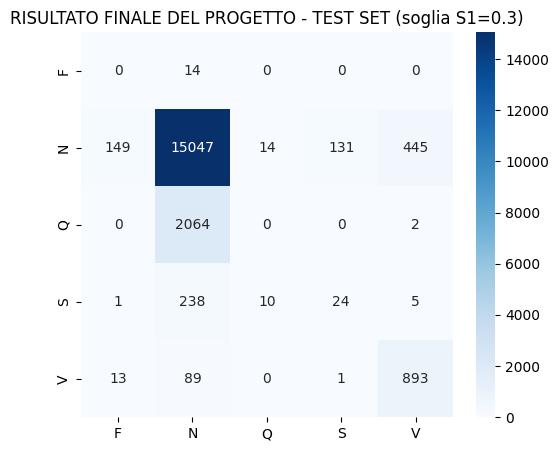

              precision    recall  f1-score   support

           F       0.00      0.00      0.00        14
           N       0.86      0.95      0.91     15786
           Q       0.00      0.00      0.00      2066
           S       0.15      0.09      0.11       278
           V       0.66      0.90      0.76       996

    accuracy                           0.83     19140
   macro avg       0.34      0.39      0.36     19140
weighted avg       0.75      0.83      0.79     19140


>>> MACRO F1 FINALE SUL TEST SET: 0.3558


In [ ]:
pred_test_finale = pipeline_combinata(X_test, rr_test_norm, model_stadio1, SOGLIA_S1, model_stadio2, soglie_per_classe, indice_N, classe_to_int, int_to_classe_s2)

cm_test = confusion_matrix(y_test, pred_test_finale, labels=list(range(num_classi)))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', xticklabels=nomi_classi_finali, yticklabels=nomi_classi_finali, cmap='Blues')
plt.title(f'RISULTATO FINALE DEL PROGETTO - TEST SET (soglia S1={SOGLIA_S1})')
plt.show()

print(classification_report(y_test, pred_test_finale, labels=list(range(num_classi)), target_names=nomi_classi_finali, zero_division=0))
print(f"\n>>> MACRO F1 FINALE SUL TEST SET: {f1_score(y_test, pred_test_finale, labels=list(range(num_classi)), average='macro', zero_division=0):.4f}")

## 10. Salvataggio dei modelli finali su Drive

In [ ]:
model_stadio1.save(f'{SALVA_DIR}/modello_stadio1.keras')
model_stadio2.save(f'{SALVA_DIR}/modello_stadio2.keras')

import json
config_finale = {
    'soglia_s1': float(SOGLIA_S1),
    'soglie_classe_s2': {nomi_s2[k]: float(v) for k, v in soglie_per_classe.items()},
    'rr_media': float(rr_media),
    'rr_std': float(rr_std)
}
with open(f'{SALVA_DIR}/config_finale.json', 'w') as f:
    json.dump(config_finale, f, indent=2)

print('Modelli e configurazione finale salvati su Drive.')
print(config_finale)

Modelli e configurazione finale salvati su Drive.
{'soglia_s1': 0.3, 'soglie_classe_s2': {'F': 0.55, 'Q': 0.85, 'S': 0.55, 'V': 0.9}, 'rr_media': 287.5957126861785, 'rr_std': 155.86146337373097}
